# 12.8 每個時間框，如何變成一條聲音特徵？


一段 0.1 秒單音經 log-mel 處理，得到 16 個頻帶、11 個時間框。現在希望每框用 8 個數字表示，依先後排成 11 條特徵，供後面的模型逐位置讀取；這一步不把整段平均成一個數字。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

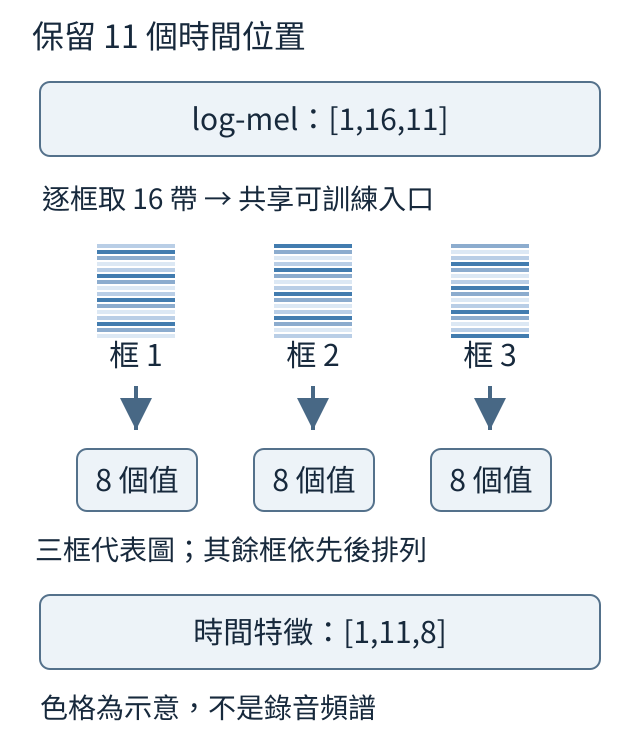

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-12-frame-features.svg")))

In [3]:
from tiny_perceptron.multimodal import tone, log_mel, AudioEncoder

wave = tone()[None]
spectrogram = log_mel(wave)
encoder = AudioEncoder(bands=16, width=8)
features = encoder(wave)
print("頻譜", tuple(spectrogram.shape))
print("時間特徵", tuple(features.shape))

頻譜 (1, 16, 11)
時間特徵 (1, 11, 8)


`tone()` 先產生一維波形；`[None]` 在最前面新增大小為 1 的軸，讓輸入表示一筆聲音。獨立算出的 `spectrogram` 用來列印並對照形狀；`encoder(wave)` 接收波形後，會在內部先算 log-mel，再調軸並套用逐框入口。程式印出頻譜 `(1,16,11)`、時間特徵 `(1,11,8)`。第一軸的 1 是一段聲音；頻譜表先按「頻帶、時間」保存，入口轉成「時間、頻帶」，讓同一組可訓練配方對每框的 16 個值產生 8 個輸出。本入口先做線性投影，再經正規化、另一線性層與非線性函數GELU，這些運算都保持時間位置。11 個位置仍代表時間框，不是 11 個字。

16 轉 8 是每框的摘要，與把 11 框全部平均掉不同。前者仍能表示哪種變化先來；後者可能只留整體多寡。配方共享表示每框使用同一入口，不表示隨機初始化的 8 個數字已經認得聲音。

入口要從任務材料學出有用特徵。單音任務可以教「頻率高於 300 Hz 回 high，否則 low」；真人短句的有限需求則需要真人錄音與需求標註。兩種答案不是同一件事：前者只驗證單音高低，不能據此宣稱聽懂中文問句。

下一節先用單音檢查接到文字核心後的梯度通路；[12.15](https://birdhackor.github.io/tiny-perceptron-vlm/12.15.html) 再設計真人短句意圖入口。這樣頻譜轉特徵是共同機制，各任務仍有各自材料與判準。

練習只把入口 width 改成 12，時間特徵應為 `(1,11,12)`，原本 log-mel 頻帶仍為 16。若想用 32 帶，前處理與入口的 bands 都要一致，不能只改一邊。

<details>
<summary>回顧與查證</summary>

可回顧：[12.7的log-mel](https://birdhackor.github.io/tiny-perceptron-vlm/12.7.html)、[10.3的共享線性變換](https://birdhackor.github.io/tiny-perceptron-vlm/10.3.html)、[W.3軸順序](https://birdhackor.github.io/tiny-perceptron-vlm/first-steps.html#W.3)。

原實驗的資料切分、更新設定與逐題結果見[既有實報](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/results/encoders.json)；重做入口見[實驗說明](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/README.md)。這是上述有限任務的歷史紀錄。

</details>
